In [5]:
import torch
import torchvision
import torchvision.transforms as transforms

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [7]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
# images shape: (64, 3, 32, 32), labels shape: (64,)

image = images[0]   # First image in the batch, shape (3, 32, 32)
label = labels[0]   # Its label (tensor int)

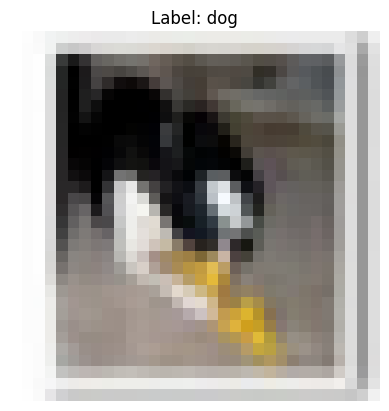

In [10]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

def show_image(img, label):
    img = img / 2 + 0.5      # Unnormalize from [-1, 1] back to [0, 1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # (C,H,W) → (H,W,C)
    plt.title(f"Label: {classes[label]}")
    plt.axis('off')
    plt.show()

show_image(image, label.item())

In [13]:
import torch.nn as nn

#tiny nn.Module class that takes an input of shape (B, 10) and outputs (B, 5) using a single nn.Linear
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(10,5)

    def forward(self, x):
        return self.layer(x)

x = torch.randn(1, 10)

my_module = MyModule()
y = my_module(x)
y.shape

torch.Size([1, 5])

In [18]:
conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=4, stride=4)

x = torch.randn(1,3,16,16)

y = conv(x)
y.shape

torch.Size([1, 8, 4, 4])

In [57]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=128):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        num_patches = (img_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, d_model))
        self.projection = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.projection(x).flatten(start_dim=2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        return x + self.pos_embedding

In [58]:
x = torch.randn(1, 3, 32, 32)
pe = PatchEmbedding()
print(pe(x).shape)

torch.Size([1, 65, 128])


In [59]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=128, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, S, _ = x.shape
        q = self.q_proj(x).reshape(B, S, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).reshape(B, S, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).reshape(B, S, self.num_heads, self.head_dim).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / self.head_dim ** 0.5
        attn_weights = torch.softmax(scores, dim=-1)
        attn_output = (attn_weights @ v).transpose(1, 2).reshape(B, S, -1)
        return self.out_proj(attn_output)
        

In [60]:
x = torch.randn(1, 65, 128)
mha = MultiHeadAttention()
print(mha(x).shape)  # should be (1, 65, 128)

torch.Size([1, 65, 128])


In [61]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=4, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * mlp_ratio),
            nn.GELU(),
            nn.Linear(d_model * mlp_ratio, d_model)
        )

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [62]:
x = torch.randn(1, 65, 128)
block = TransformerBlock()
print(block(x).shape)  # should be (1, 65, 128)

torch.Size([1, 65, 128])


In [69]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=128, num_heads=4, num_layers=6, num_classes=10):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        self.encoder = nn.Sequential(*[TransformerBlock(d_model, num_heads) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.classifier(cls_token)

In [70]:
model = ViT()
x = torch.randn(1, 3, 32, 32)
print(model(x).shape)  # should be (1, 10)

torch.Size([1, 10])


In [73]:
for epoch in range(5):
    running_loss = 0.0
    for i, (images, labels) in enumerate(trainloader):
        predictions = model(images)
        loss = criterion(predictions, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(f"Epoch {epoch+1}, Batch {i+1}, Loss: {running_loss / 100:.4f}")
            running_loss = 0.0

Epoch 1, Batch 100, Loss: 1.6945
Epoch 1, Batch 200, Loss: 1.6290
Epoch 1, Batch 300, Loss: 1.6259
Epoch 1, Batch 400, Loss: 1.5644
Epoch 1, Batch 500, Loss: 1.5464
Epoch 1, Batch 600, Loss: 1.5160
Epoch 1, Batch 700, Loss: 1.4806
Epoch 2, Batch 100, Loss: 1.4232
Epoch 2, Batch 200, Loss: 1.4395
Epoch 2, Batch 300, Loss: 1.4342
Epoch 2, Batch 400, Loss: 1.4000
Epoch 2, Batch 500, Loss: 1.3909
Epoch 2, Batch 600, Loss: 1.3998
Epoch 2, Batch 700, Loss: 1.3705
Epoch 3, Batch 100, Loss: 1.3319
Epoch 3, Batch 200, Loss: 1.3294
Epoch 3, Batch 300, Loss: 1.3050
Epoch 3, Batch 400, Loss: 1.3109
Epoch 3, Batch 500, Loss: 1.2974
Epoch 3, Batch 600, Loss: 1.2935
Epoch 3, Batch 700, Loss: 1.2727
Epoch 4, Batch 100, Loss: 1.2237
Epoch 4, Batch 200, Loss: 1.2306
Epoch 4, Batch 300, Loss: 1.2374
Epoch 4, Batch 400, Loss: 1.2227
Epoch 4, Batch 500, Loss: 1.2233
Epoch 4, Batch 600, Loss: 1.2082
Epoch 4, Batch 700, Loss: 1.2142
Epoch 5, Batch 100, Loss: 1.1610
Epoch 5, Batch 200, Loss: 1.1670
Epoch 5, B

In [78]:
def evaluate(model, testloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    print(f"Accuracy: {100 * correct / total:.2f}%")

In [79]:
evaluate(model, testloader)

Accuracy: 55.57%
